First 10 Rows:
   region  tenure  age  income  marital  address  ed  employ  retire  gender  \
0       2      13   44      64        1        9   4       5       0       0   
1       3      11   33     136        1        7   5       5       0       0   
2       3      68   52     116        1       24   1      29       0       1   
3       2      33   33      33        0       12   2       0       0       1   
4       2      23   30      30        1        9   1       2       0       0   
5       2      41   39      78        0       17   2      16       0       1   
6       3      45   22      19        1        2   2       4       0       1   
7       2      38   35      76        0        5   2      10       0       0   
8       3      45   59     166        1        7   4      31       0       0   
9       1      68   41      72        1       21   1      22       0       0   

   reside custcat  
0       2       A  
1       6       D  
2       2       C  
3       1       A  
4   

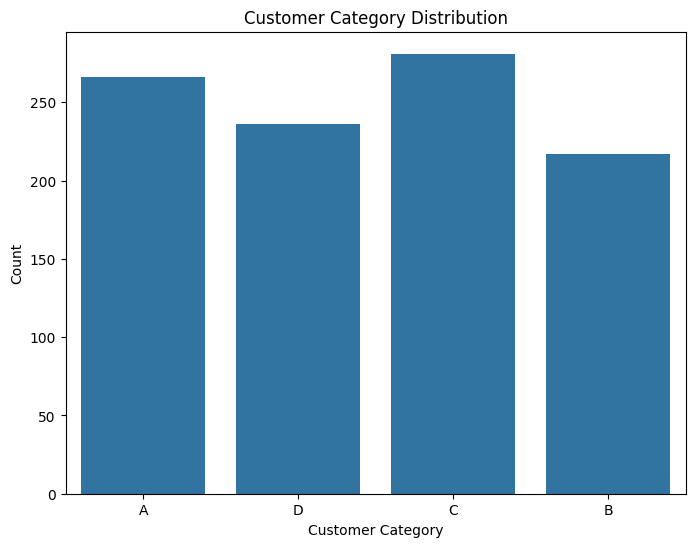

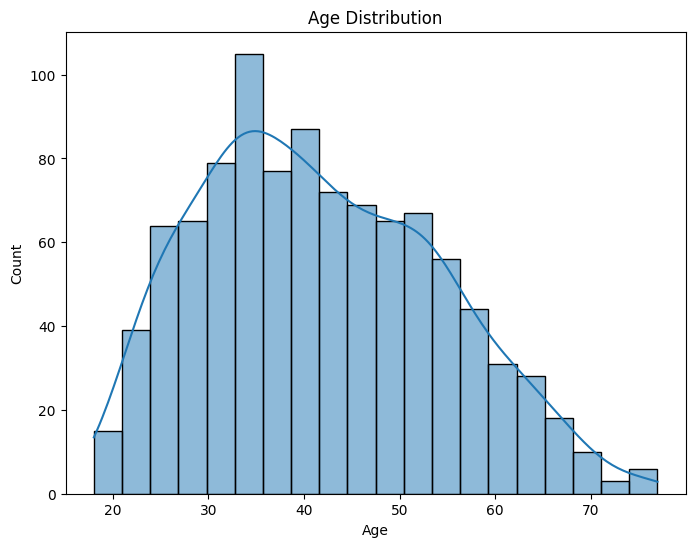

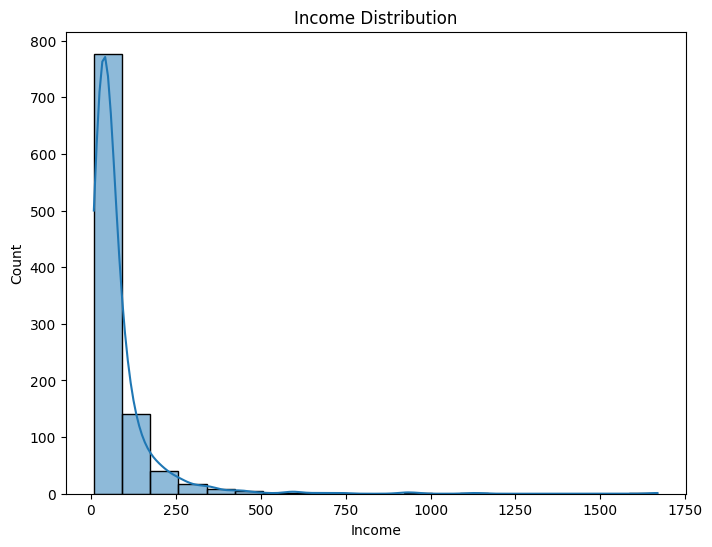

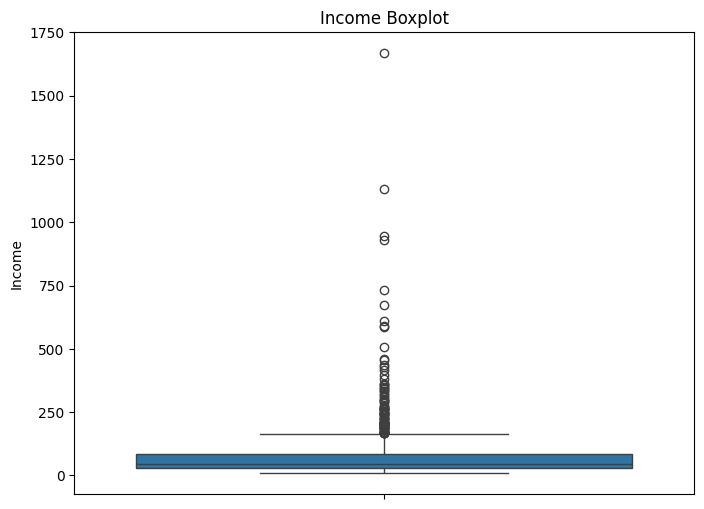

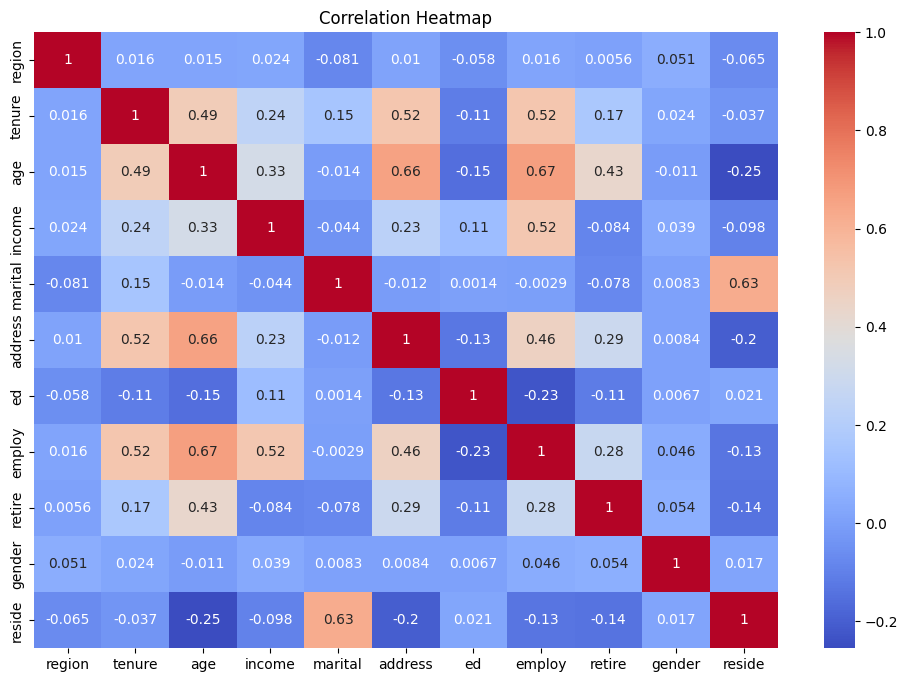


Independent Variables:
Index(['region', 'tenure', 'age', 'income', 'marital', 'address', 'ed',
       'employ', 'retire', 'gender', 'reside'],
      dtype='object')

Dependent Variable:
custcat

Training Set Shape:
(750, 11)

Testing Set Shape:
(250, 11)

Initial Decision Tree Accuracy:
0.28

Initial Decision Tree Confusion Matrix:
[[21 14 17 15]
 [14 11 14 15]
 [15 17 23 15]
 [11 19 14 15]]

Initial Decision Tree Classification Report:
              precision    recall  f1-score   support

           A       0.34      0.31      0.33        67
           B       0.18      0.20      0.19        54
           C       0.34      0.33      0.33        70
           D       0.25      0.25      0.25        59

    accuracy                           0.28       250
   macro avg       0.28      0.27      0.28       250
weighted avg       0.28      0.28      0.28       250


Best Parameters from GridSearchCV:
{'criterion': 'entropy', 'max_depth': 3, 'max_features': None, 'min_samples_leaf': 1, '

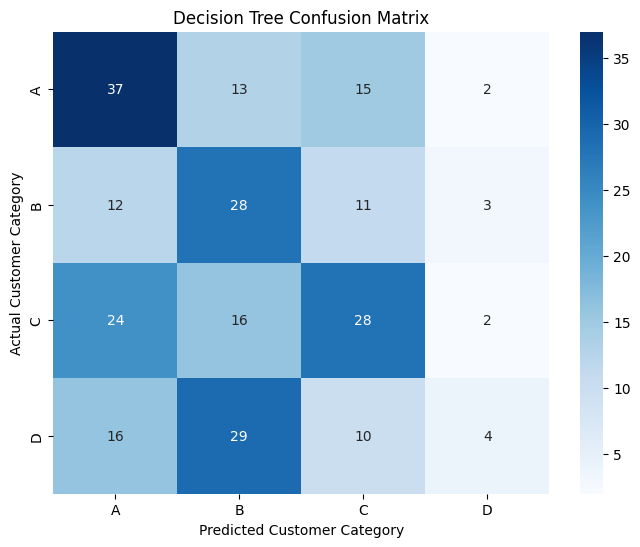


Feature Importance:
    Feature  Importance
6        ed    0.496616
1    tenure    0.383084
5   address    0.063542
10   reside    0.056758
0    region    0.000000
2       age    0.000000
4   marital    0.000000
3    income    0.000000
7    employ    0.000000
8    retire    0.000000
9    gender    0.000000


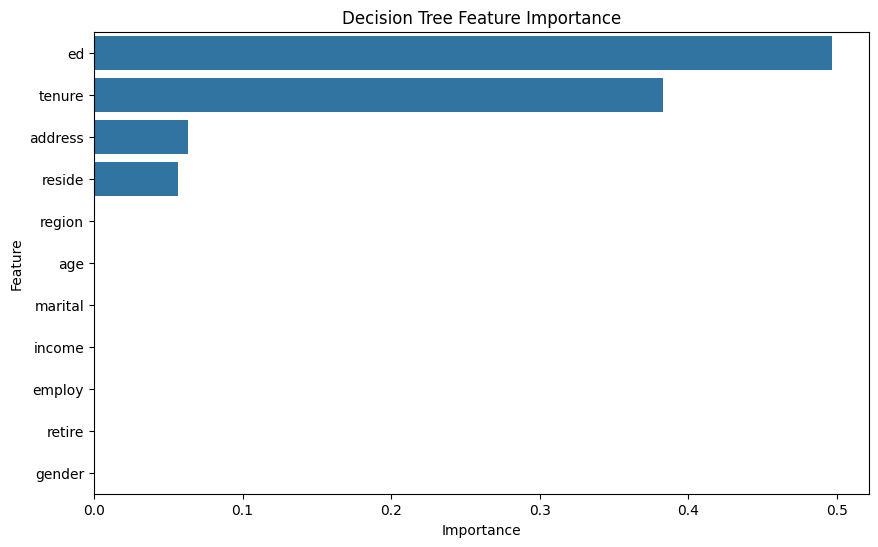

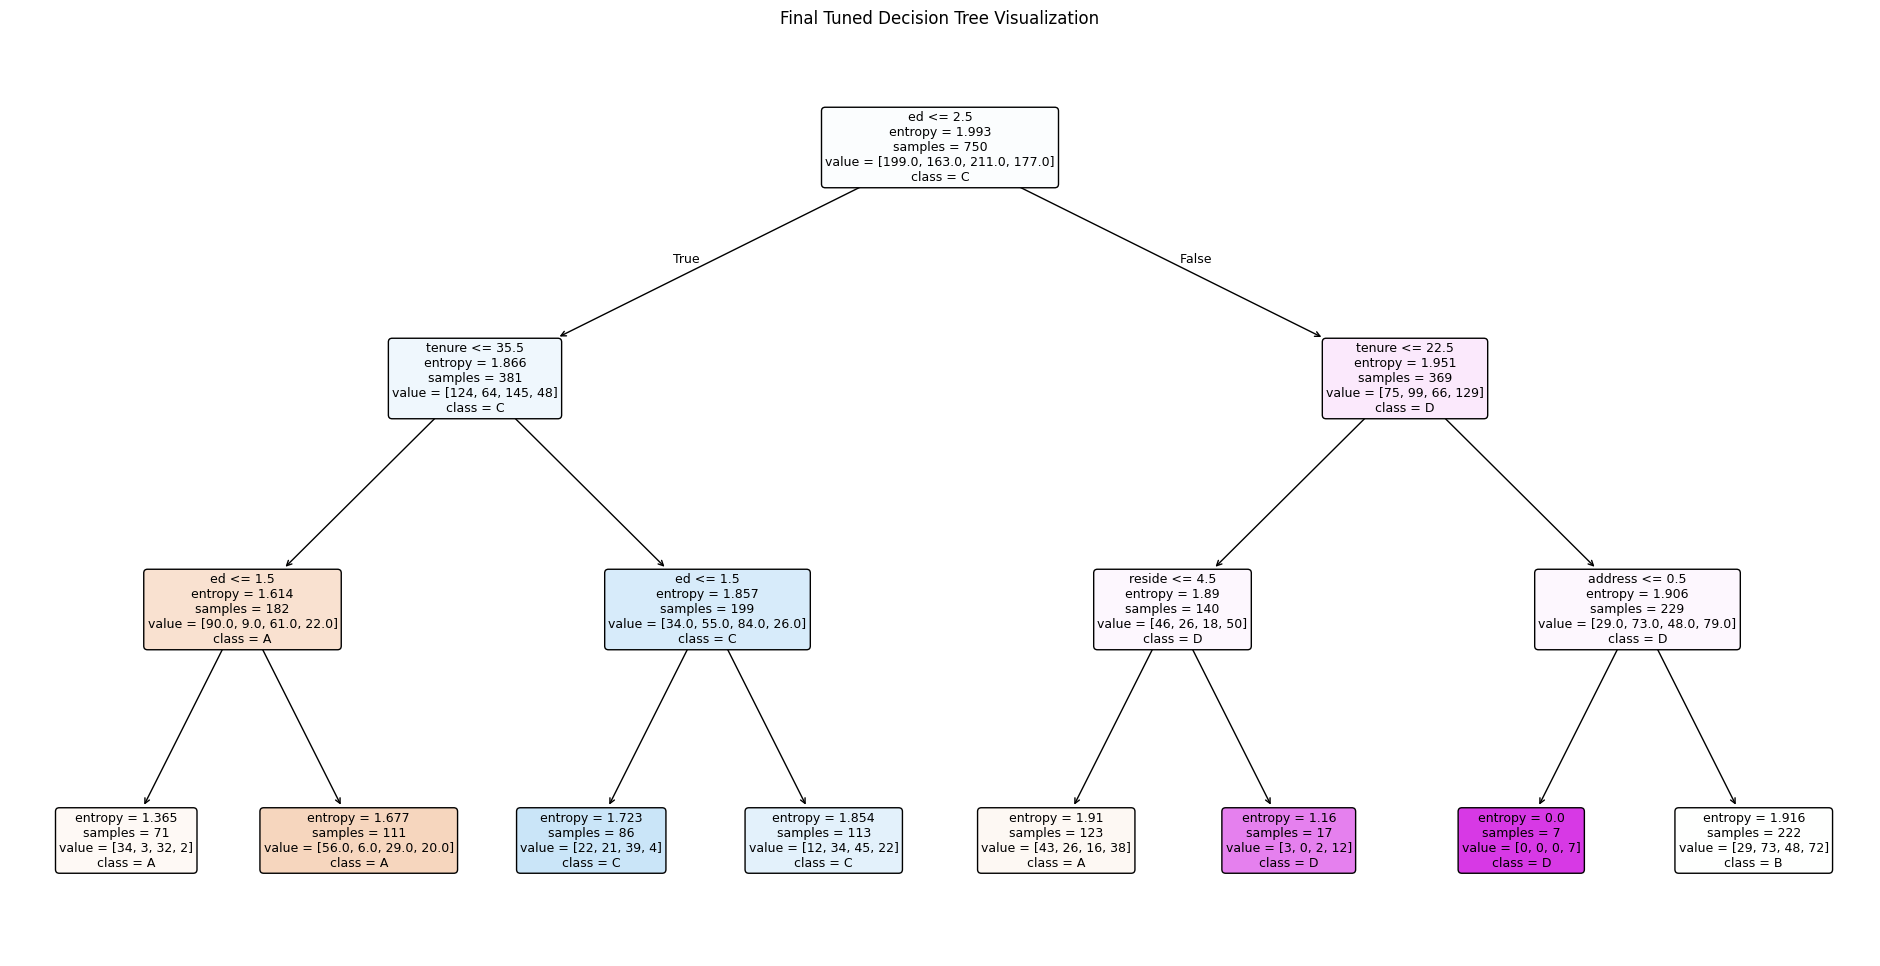


Decision Tree Model Properties:
Tree Depth: 3
Number of Leaves: 8
Criterion: entropy
Classes: ['A' 'B' 'C' 'D']

Model Comparison:
Initial Accuracy: 0.28
Final Tuned Accuracy: 0.388
Accuracy Improvement: 0.10799999999999998


In [1]:
# ============================================
# DATA 430 Assignment 3 - Decision Trees
# Customer Segmentation Classification
# Retuned Full Code
# ============================================

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

%matplotlib inline

# --------------------------------------------
# Load Dataset
# --------------------------------------------
data = pd.read_csv('Telecust1.csv')

# --------------------------------------------
# Basic Dataset Review
# --------------------------------------------
print("First 10 Rows:")
print(data.head(10))

print("\nDataset Info:")
print(data.info())

print("\nMissing Values:")
print(data.isnull().sum())

print("\nSummary Statistics:")
print(data.describe())

print("\nCustomer Category Distribution:")
print(data['custcat'].value_counts())

# --------------------------------------------
# Correlation Matrix
# --------------------------------------------
print("\nCorrelation Matrix:")
print(data.corr(numeric_only=True))

# ============================================
# Exploratory Visualizations
# ============================================

# Figure 1: Customer Category Distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='custcat', data=data)
plt.title('Customer Category Distribution')
plt.xlabel('Customer Category')
plt.ylabel('Count')
plt.show()

# Figure 2: Age Distribution
plt.figure(figsize=(8, 6))
sns.histplot(data['age'], bins=20, kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

# Figure 3: Income Distribution
plt.figure(figsize=(8, 6))
sns.histplot(data['income'], bins=20, kde=True)
plt.title('Income Distribution')
plt.xlabel('Income')
plt.ylabel('Count')
plt.show()

# Figure 4: Income Boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(y=data['income'])
plt.title('Income Boxplot')
plt.ylabel('Income')
plt.show()

# Figure 5: Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# ============================================
# Preprocessing
# ============================================

# Define independent variables and target variable
X = data.drop(columns=['custcat'])
y = data['custcat']

print("\nIndependent Variables:")
print(X.columns)

print("\nDependent Variable:")
print("custcat")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("\nTraining Set Shape:")
print(X_train.shape)

print("\nTesting Set Shape:")
print(X_test.shape)

# ============================================
# Initial Decision Tree Model
# ============================================

initial_tree = DecisionTreeClassifier(
    random_state=42
)

initial_tree.fit(X_train, y_train)

initial_predictions = initial_tree.predict(X_test)

print("\nInitial Decision Tree Accuracy:")
print(accuracy_score(y_test, initial_predictions))

print("\nInitial Decision Tree Confusion Matrix:")
print(confusion_matrix(y_test, initial_predictions))

print("\nInitial Decision Tree Classification Report:")
print(classification_report(y_test, initial_predictions, zero_division=0))

# ============================================
# Improved Hyperparameter Tuning
# ============================================

param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 4, 5, 6, 8, 10, 12, 15, None],
    'min_samples_split': [2, 5, 10, 15, 20],
    'min_samples_leaf': [1, 2, 4, 6, 8],
    'max_features': [None, 'sqrt', 'log2']
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("\nBest Parameters from GridSearchCV:")
print(grid_search.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(grid_search.best_score_)

# ============================================
# Final Tuned Decision Tree Model
# ============================================

best_tree = grid_search.best_estimator_

best_tree.fit(X_train, y_train)

final_predictions = best_tree.predict(X_test)

print("\nFinal Tuned Decision Tree Accuracy:")
print(accuracy_score(y_test, final_predictions))

print("\nFinal Tuned Decision Tree Confusion Matrix:")
print(confusion_matrix(y_test, final_predictions))

print("\nFinal Tuned Decision Tree Classification Report:")
print(classification_report(y_test, final_predictions, zero_division=0))

# ============================================
# Confusion Matrix Heatmap
# ============================================

cm = confusion_matrix(y_test, final_predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=best_tree.classes_,
    yticklabels=best_tree.classes_
)
plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted Customer Category')
plt.ylabel('Actual Customer Category')
plt.show()

# ============================================
# Feature Importance
# ============================================

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_tree.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nFeature Importance:")
print(feature_importance)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)
plt.title('Decision Tree Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

# ============================================
# Decision Tree Visualization
# ============================================

plt.figure(figsize=(24, 12))
plot_tree(
    best_tree,
    feature_names=X.columns,
    class_names=best_tree.classes_,
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title('Final Tuned Decision Tree Visualization')
plt.show()

# ============================================
# Model Properties
# ============================================

print("\nDecision Tree Model Properties:")
print("Tree Depth:", best_tree.get_depth())
print("Number of Leaves:", best_tree.get_n_leaves())
print("Criterion:", best_tree.criterion)
print("Classes:", best_tree.classes_)

# ============================================
# Optional: Compare Initial vs Tuned Accuracy
# ============================================

initial_accuracy = accuracy_score(y_test, initial_predictions)
final_accuracy = accuracy_score(y_test, final_predictions)

print("\nModel Comparison:")
print("Initial Accuracy:", initial_accuracy)
print("Final Tuned Accuracy:", final_accuracy)
print("Accuracy Improvement:", final_accuracy - initial_accuracy)